1. Instalando e importar bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

2. Carregando os arquivos CSV

In [2]:
sessions = pd.read_csv("/content/Case Analista de Dados — the news [Dataset Palavritas] - palavritas_sessions.csv")
attempts = pd.read_csv("/content/Case Analista de Dados — the news [Dataset Palavritas] - palavritas_attempts.csv")
profile = pd.read_csv("/content/Case Analista de Dados — the news [Dataset Palavritas] - user_profile.csv")

3. Visualizando as bases

In [3]:
print("Sessions:", sessions.shape)
print("Attempts:", attempts.shape)
print("Profile:", profile.shape)



Sessions: (41157, 13)
Attempts: (147270, 5)
Profile: (800, 15)


In [4]:
sessions.head()

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30
0,ab38635a07ede4246661,697e9e150e91bb76,TEMPO,2026-02-08,1,win,449,Android,20,2,False,False,False
1,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,lose,232,ios,19,1,True,False,False
2,3635c5707f62ea022423,6220de621fef79b8,FALHA,2026-04-18,3,win,65,iOS,7,2,False,False,False
3,27243d4c7b1669f71ba7,3aa2f6a86d7fe06c,PRATO,2025-12-22,6,lose,404,Android,23,2,False,False,True
4,cd21162dd072f066c160,97af736a7f2aa637,IDEIA,2026-05-28,1,win,222,Android,6,2,False,True,False


In [5]:
attempts.head()

,session_id,attempt_number,guess,correct_letters,correct_positions
0,ab38635a07ede4246661,1,TEMPO,0,5
1,67d40a22cba1a16fd2c5,1,NOVAS,1,0
2,67d40a22cba1a16fd2c5,2,OUVIR,0,0
3,67d40a22cba1a16fd2c5,3,NOVAS,1,0
4,67d40a22cba1a16fd2c5,4,VAPOR,0,1


In [6]:
profile.head()

,user_id,age_range,state,city,salary_range,job_role,sector,company_size,orders_food_delivery,food_delivery_freq_week,food_delivery_platform,primary_device,plays_other_word_games,typical_play_time,newsletter_subscriber
0,fe2e4f159653f26f,NaN,MG,NaN,R$4k-R$6k,Consultor,finanças,pequena,True,5,Rappi,Android,True,afternoon,True
1,4d89d721da20cbc3,35-44,MG,Rio de Janeiro,R$4k-R$6k,analista,educação,multinacional,True,3,Ambos,iOS,True,morning,True
2,91bf47f1274e23a8,25-34,PB,NaN,NaN,Coordenador,tech,pequena,True,3,Nenhum,Android,True,morning,True
3,4efe31b67538c37f,25-34,PB,NaN,até R$2k,Gerente,finanças,grande,True,5,Nenhum,iOS,False,afternoon,False
4,d6af92f33a83c685,18-24,RN,Belo Horizonte,até R$2k,consultor,outros,pequena,False,0,Nenhum,Android,True,evening,False


4. Diagnóstico inicial dos dados

In [7]:
def diagnostico(df, nome):
    print(f"\n===== {nome} =====")
    print("Linhas e colunas:", df.shape)
    print("\nTipos de dados:")
    print(df.dtypes)
    print("\nValores nulos:")
    print(df.isna().sum())
    print("\nDuplicados:")
    print(df.duplicated().sum())

diagnostico(sessions, "palavritas_sessions")
diagnostico(attempts, "palavritas_attempts")
diagnostico(profile, "user_profile")


===== palavritas_sessions =====
Linhas e colunas: (41157, 13)

Tipos de dados:
session_id                     object
user_id                        object
word                           object
word_date                      object
attempts                        int64
result                         object
time_to_complete_sec            int64
device                         object
session_hour                    int64
streak_day                      int64
played_next_day                  bool
newsletter_open_before_game      bool
active_d30                       bool
dtype: object

Valores nulos:
session_id                      0
user_id                         0
word                            0
word_date                       0
attempts                        0
result                         63
time_to_complete_sec            0
device                          0
session_hour                    0
streak_day                      0
played_next_day                 0
newsletter_open_before

5. Diagnóstico de valores únicos

In [8]:
for col in sessions.columns:
    print(f"\n{col}")
    print(sessions[col].value_counts(dropna=False).head(10))


session_id
session_id
246d7a566541305e117d    2
20a4aa6bda6342ec474f    2
4bea4edc2d468c4a711c    2
a914cdfc1748f2f3f343    2
f7b4afd2d635f3d9263c    2
463e6de678924deba55a    2
4d4eaf9d070d8c7b7a5a    2
47c55dc591e27fe6180a    2
ddfaf72d3a91a9f76fcb    2
8ba09ce425a0437aa9c2    2
Name: count, dtype: int64

user_id
user_id
7f772a483b95fd44    66
ea739162cc1e0e61    64
6dac31494d13e2b2    64
c48e5e85d0ab70ca    64
3cde33bc4b5cd0aa    63
00f3b528c9a28fc1    63
039279ad8348a9f5    63
108876366fb542f2    63
2963db28f598dece    63
79214fed491f4470    63
Name: count, dtype: int64

word
word
PRATO    3696
CORVO    2788
HERÓI    2679
NUVEM    2677
TEMPO    1845
FALHA    1842
VENTO    1835
PAZÃO    1820
CASCA    1820
BARCO    1796
Name: count, dtype: int64

word_date
word_date
2026-05-24    239
2026-05-08    230
2026-01-23    225
2026-01-30    225
2026-05-07    224
2026-04-21    224
2026-02-17    219
2026-03-03    216
2025-12-12    215
2026-03-01    213
Name: count, dtype: int64

attempts
atte

6. Limpeza da base sessions

In [9]:
sessions_clean = sessions.copy()

# Remover duplicados por session_id
sessions_clean = sessions_clean.drop_duplicates(subset=["session_id"])

# Converter data
sessions_clean["word_date"] = pd.to_datetime(
    sessions_clean["word_date"],
    errors="coerce"
)

# Padronizar texto
sessions_clean["result"] = sessions_clean["result"].str.lower().str.strip()
sessions_clean["device"] = sessions_clean["device"].str.lower().str.strip()
sessions_clean["word"] = sessions_clean["word"].str.lower().str.strip()

# Manter apenas resultados válidos
sessions_clean = sessions_clean[
    sessions_clean["result"].isin(["win", "lose"])
]

# Manter tentativas válidas entre 1 e 6
sessions_clean = sessions_clean[
    sessions_clean["attempts"].between(1, 6)
]

# Manter horário válido entre 0 e 23
sessions_clean = sessions_clean[
    sessions_clean["session_hour"].between(0, 23)
]

7. Limpeza da base attempts

In [10]:
attempts_clean = attempts.copy()

attempts_clean = attempts_clean.drop_duplicates()

attempts_clean["guess"] = attempts_clean["guess"].str.lower().str.strip()

attempts_clean = attempts_clean[
    attempts_clean["attempt_number"].between(1, 6)
]

8. Limpeza da base profile

In [11]:
profile_clean = profile.copy()

profile_clean = profile_clean.drop_duplicates(subset=["user_id"])

cols_texto = [
    "age_range", "state", "city", "salary_range", "job_role",
    "sector", "company_size", "food_delivery_platform",
    "primary_device", "typical_play_time"
]

for col in cols_texto:
    if col in profile_clean.columns:
        profile_clean[col] = profile_clean[col].astype(str).str.lower().str.strip()

9. Documentando o que foi limpo

In [12]:
resumo_limpeza = pd.DataFrame({
    "base": ["sessions", "attempts", "profile"],
    "linhas_originais": [len(sessions), len(attempts), len(profile)],
    "linhas_pos_limpeza": [len(sessions_clean), len(attempts_clean), len(profile_clean)],
})

resumo_limpeza["linhas_removidas"] = (
    resumo_limpeza["linhas_originais"] - resumo_limpeza["linhas_pos_limpeza"]
)

resumo_limpeza

,base,linhas_originais,linhas_pos_limpeza,linhas_removidas
0,sessions,41157,39849,1308
1,attempts,147270,146477,793
2,profile,800,800,0


10. Criar variáveis de análise

In [13]:
sessions_clean["venceu"] = np.where(sessions_clean["result"] == "win", 1, 0)

sessions_clean["tempo_minutos"] = (
    sessions_clean["time_to_complete_sec"] / 60
)

sessions_clean["periodo_jogo"] = pd.cut(
    sessions_clean["session_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["madrugada", "manhã", "tarde", "noite"]
)

11. Juntar sessions com profile

In [14]:
df = sessions_clean.merge(
    profile_clean,
    on="user_id",
    how="left"
)

df.shape

(39849, 30)

12. Taxas gerais

In [15]:
taxa_next_day = df["played_next_day"].mean()
taxa_active_d30 = df["active_d30"].mean()
taxa_win = df["venceu"].mean()

print(f"Taxa de retorno no dia seguinte: {taxa_next_day:.2%}")
print(f"Taxa de usuários ativos D30: {taxa_active_d30:.2%}")
print(f"Taxa de vitória: {taxa_win:.2%}")

Taxa de retorno no dia seguinte: 22.14%
Taxa de usuários ativos D30: 31.94%
Taxa de vitória: 60.34%


13. Função para análise por variável

In [16]:
def analise_retencao(df, coluna):
    resultado = (
        df.groupby(coluna)
        .agg(
            sessoes=("session_id", "count"),
            usuarios=("user_id", "nunique"),
            taxa_next_day=("played_next_day", "mean"),
            taxa_active_d30=("active_d30", "mean"),
            taxa_vitoria=("venceu", "mean"),
            tentativas_media=("attempts", "mean"),
            tempo_medio_min=("tempo_minutos", "mean")
        )
        .reset_index()
        .sort_values("taxa_next_day", ascending=False)
    )

    return resultado

14. Análise por horário do jogo

In [17]:
analise_horario = analise_retencao(df, "periodo_jogo")
analise_horario

/tmp/ipykernel_21300/3233184331.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(coluna)


,periodo_jogo,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
2,tarde,8305,242,0.225888,0.297652,0.528838,3.889946,4.486119
3,noite,18987,572,0.220361,0.291673,0.533523,3.857007,4.495341
1,manhã,12557,386,0.220037,0.375647,0.758223,2.967906,4.511992
0,madrugada,0,0,NaN,NaN,NaN,NaN,NaN


15. Análise por hora exata


In [18]:
analise_hora = analise_retencao(df, "session_hour")
analise_hora.head(24)

,session_hour,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
6,15,1412,234,0.247167,0.342776,0.530453,3.878895,4.517458
5,14,1385,234,0.238989,0.280144,0.541516,3.849819,4.510650
14,23,4169,249,0.235548,0.304629,0.544735,3.811945,4.475969
1,7,4252,383,0.228833,0.384760,0.754233,2.974130,4.546355
4,13,1401,231,0.227695,0.291221,0.551035,3.803712,4.433500
8,17,1373,237,0.226511,0.310269,0.522214,3.923525,4.446261
12,21,2776,318,0.224784,0.296830,0.530620,3.873199,4.478050
2,8,4160,384,0.219471,0.378365,0.760817,2.975000,4.514876
11,20,2580,320,0.218605,0.280620,0.529845,3.862791,4.546150
13,22,4159,249,0.217119,0.289252,0.529454,3.866795,4.486327


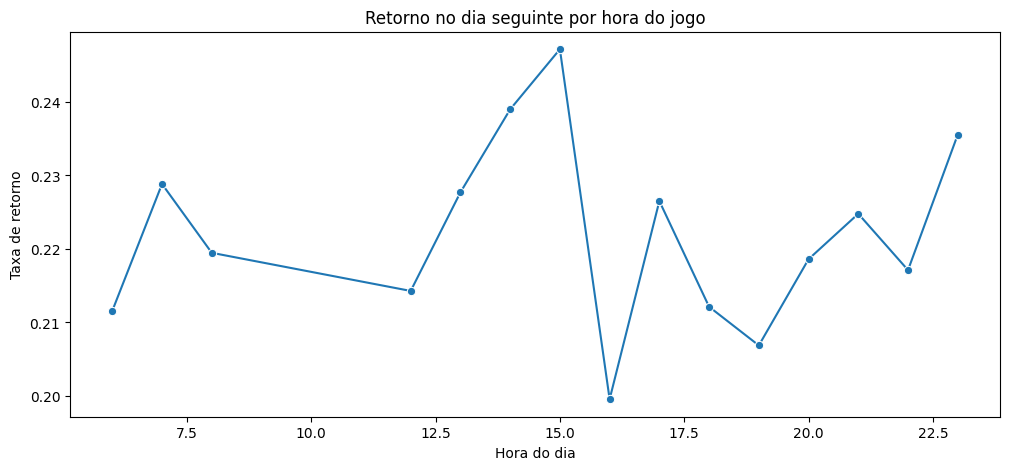

In [19]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=analise_hora,
    x="session_hour",
    y="taxa_next_day",
    marker="o"
)

plt.title("Retorno no dia seguinte por hora do jogo")
plt.ylabel("Taxa de retorno")
plt.xlabel("Hora do dia")
plt.show()

16. Análise da newsletter

In [20]:
analise_newsletter = analise_retencao(
    df,
    "newsletter_open_before_game"
)

analise_newsletter

,newsletter_open_before_game,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
0,False,32198,1197,0.222840,0.305423,0.563793,3.740947,4.492927
1,True,7651,336,0.215397,0.378121,0.769834,2.921971,4.522816


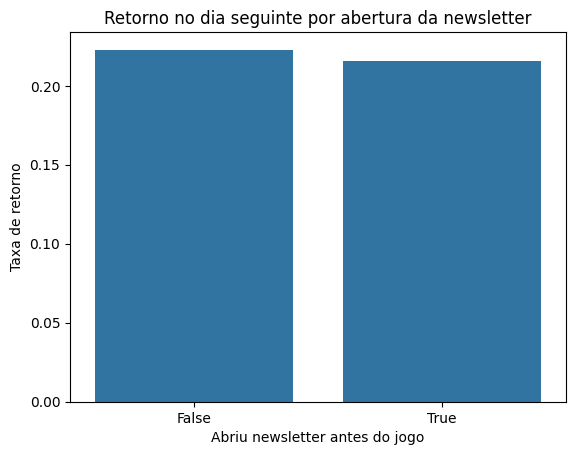

In [21]:
sns.barplot(
    data=analise_newsletter,
    x="newsletter_open_before_game",
    y="taxa_next_day"
)

plt.title("Retorno no dia seguinte por abertura da newsletter")
plt.ylabel("Taxa de retorno")
plt.xlabel("Abriu newsletter antes do jogo")
plt.show()

17. Análise por dispositivo

In [22]:
analise_device = analise_retencao(df, "device")
analise_device

,device,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
1,ios,21738,646,0.222790,0.320407,0.580274,3.674441,4.499688
0,android,18111,554,0.219756,0.318149,0.631053,3.474794,4.497439


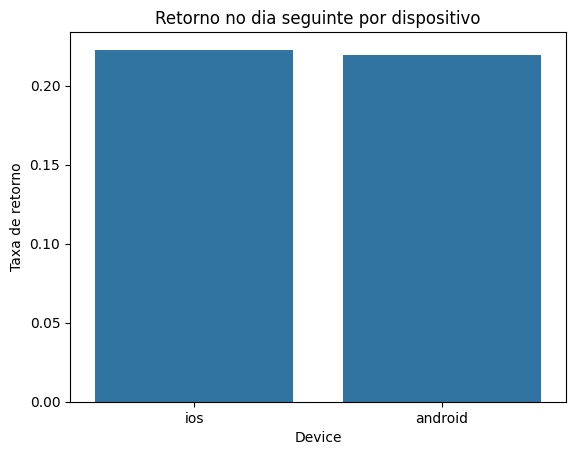

In [23]:
sns.barplot(
    data=analise_device,
    x="device",
    y="taxa_next_day"
)

plt.title("Retorno no dia seguinte por dispositivo")
plt.ylabel("Taxa de retorno")
plt.xlabel("Device")
plt.show()

18. Análise por streak

In [24]:
df["faixa_streak"] = pd.cut(
    df["streak_day"],
    bins=[-1, 0, 2, 6, 13, 30, 999],
    labels=[
        "sem streak",
        "1-2 dias",
        "3-6 dias",
        "7-13 dias",
        "14-30 dias",
        "30+ dias"
    ]
)

analise_streak = analise_retencao(df, "faixa_streak")
analise_streak

/tmp/ipykernel_21300/3233184331.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(coluna)


,faixa_streak,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
3,7-13 dias,12,9,0.250000,0.250000,0.750000,3.000000,3.386111
2,3-6 dias,2085,670,0.248441,0.321343,0.601439,3.580815,4.454604
1,1-2 dias,37752,1200,0.219909,0.319294,0.603412,3.584049,4.501453
0,sem streak,0,0,NaN,NaN,NaN,NaN,NaN
4,14-30 dias,0,0,NaN,NaN,NaN,NaN,NaN
5,30+ dias,0,0,NaN,NaN,NaN,NaN,NaN


19. Análise por palavra do dia

In [25]:
analise_palavra = (
    df.groupby("word")
    .agg(
        sessoes=("session_id", "count"),
        taxa_next_day=("played_next_day", "mean"),
        taxa_active_d30=("active_d30", "mean"),
        taxa_vitoria=("venceu", "mean"),
        tentativas_media=("attempts", "mean"),
        tempo_medio_min=("tempo_minutos", "mean")
    )
    .reset_index()
)

analise_palavra = analise_palavra[
    analise_palavra["sessoes"] >= 50
]

analise_palavra.sort_values(
    "taxa_next_day",
    ascending=False
).head(10)

,word,sessoes,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
23,preto,873,0.246277,0.317297,0.658648,3.349370,4.423081
12,jogos,880,0.243182,0.321591,0.631818,3.504545,4.542936
19,pazão,1764,0.239229,0.328231,0.449546,4.195011,4.522855
27,troco,879,0.236633,0.285552,0.663254,3.356086,4.448616
16,nixão,906,0.236203,0.337748,0.461369,4.134658,4.468672
21,praia,870,0.235632,0.311494,0.648276,3.383908,4.563908
9,genro,897,0.235229,0.338907,0.670011,3.312152,4.348291
11,ideia,872,0.232798,0.329128,0.653670,3.376147,4.360780
3,ciúme,912,0.232456,0.330044,0.447368,4.231360,4.450402
25,sonho,900,0.232222,0.327778,0.643333,3.413333,4.447796


20. Palavras com menor retorno

In [26]:
analise_palavra.sort_values(
    "taxa_next_day",
    ascending=True
).head(10)

,word,sessoes,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
8,fraco,905,0.193370,0.309392,0.622099,3.472928,4.417385
26,tempo,1776,0.204392,0.323198,0.623874,3.520833,4.501689
24,rosto,898,0.204900,0.306236,0.624722,3.516704,4.624777
17,nuvem,2603,0.207453,0.298886,0.633884,3.457165,4.477616
4,corvo,2697,0.208380,0.315907,0.656656,3.352243,4.551959
13,largo,879,0.210466,0.320819,0.633675,3.488055,4.488111
15,morro,883,0.210646,0.339751,0.662514,3.354473,4.500415
1,campo,909,0.212321,0.313531,0.639164,3.430143,4.647580
22,prato,3586,0.212493,0.317624,0.647239,3.409927,4.501269
18,oraçã,837,0.213859,0.314217,0.457587,4.163680,4.517065


21. Análise de perfil: idade

In [27]:
analise_idade = analise_retencao(df, "age_range")
analise_idade

,age_range,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
3,45+,3267,95,0.238751,0.326599,0.610346,3.586471,4.506612
1,25-34,9640,284,0.225519,0.321680,0.604979,3.589834,4.481158
4,nan,3928,117,0.220978,0.317974,0.601069,3.584521,4.522951
0,18-24,3222,101,0.218498,0.322160,0.596834,3.607697,4.530157
2,35-44,6634,203,0.216008,0.323334,0.605366,3.570093,4.482560


22. Análise de perfil: salário

In [28]:
analise_salario = analise_retencao(df, "salary_range")
analise_salario

,salary_range,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
3,r$2k-r$4k,5082,152,0.231602,0.326643,0.605077,3.585793,4.544044
1,até r$2k,3309,95,0.229374,0.329707,0.621336,3.513750,4.406518
0,acima de r$10k,2834,84,0.227594,0.304869,0.564926,3.740296,4.478376
2,nan,6406,193,0.219482,0.327193,0.608336,3.559007,4.484335
4,r$4k-r$6k,5387,155,0.219046,0.323557,0.603304,3.594580,4.507716
5,r$6k-r$10k,3673,121,0.215628,0.312007,0.611762,3.566022,4.531895


23. Análise de perfil: setor

In [29]:
analise_setor = analise_retencao(df, "sector")
analise_setor.head(20)

,sector,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
1,educação,3381,101,0.236025,0.337770,0.601301,3.608696,4.488361
6,tech,6095,177,0.232978,0.323216,0.636095,3.455947,4.457107
7,varejo,2406,72,0.227348,0.330840,0.603491,3.579385,4.475222
4,outros,5066,153,0.217726,0.315239,0.606790,3.575799,4.550490
5,saúde,2547,75,0.217118,0.309776,0.564978,3.736160,4.526109
2,finanças,3766,114,0.216144,0.319703,0.594530,3.630377,4.469198
3,marketing,2030,65,0.212315,0.324138,0.580296,3.680788,4.554442
0,direito,1400,43,0.209286,0.317143,0.595714,3.613571,4.467988


24. Food delivery

In [30]:
analise_delivery = analise_retencao(df, "food_delivery_freq_week")
analise_delivery

,food_delivery_freq_week,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
5,7.0,2291,65,0.240506,0.333042,0.518551,3.912702,4.427506
1,1.0,5233,157,0.228550,0.327537,0.621059,3.518250,4.494324
2,2.0,6827,202,0.226600,0.317563,0.632489,3.477516,4.499487
4,5.0,3316,97,0.222859,0.322979,0.551568,3.792220,4.504559
3,3.0,5388,164,0.218448,0.317929,0.606162,3.571084,4.539006
0,0.0,3636,115,0.205996,0.322057,0.625688,3.514576,4.468532


25. Outros jogos de palavras

In [31]:
analise_outros_jogos = analise_retencao(
    df,
    "plays_other_word_games"
)

analise_outros_jogos

,plays_other_word_games,sessoes,usuarios,taxa_next_day,taxa_active_d30,taxa_vitoria,tentativas_media,tempo_medio_min
1,True,12368,370,0.223803,0.323496,0.603816,3.592092,4.489346
0,False,14323,430,0.222789,0.321092,0.604482,3.580535,4.503027


26. Correlação numérica

In [32]:
cols_corr = [
    "attempts",
    "time_to_complete_sec",
    "session_hour",
    "streak_day",
    "newsletter_open_before_game",
    "played_next_day",
    "active_d30",
    "venceu"
]

corr = df[cols_corr].corr(numeric_only=True)

corr[["played_next_day", "active_d30"]].sort_values(
    "played_next_day",
    ascending=False
)

,played_next_day,active_d30
played_next_day,1.000000,0.399549
active_d30,0.399549,1.000000
streak_day,0.023326,0.001057
attempts,0.008101,-0.019260
time_to_complete_sec,0.007274,0.002544
session_hour,0.002739,-0.070705
venceu,-0.006842,0.019159
newsletter_open_before_game,-0.007061,0.061415


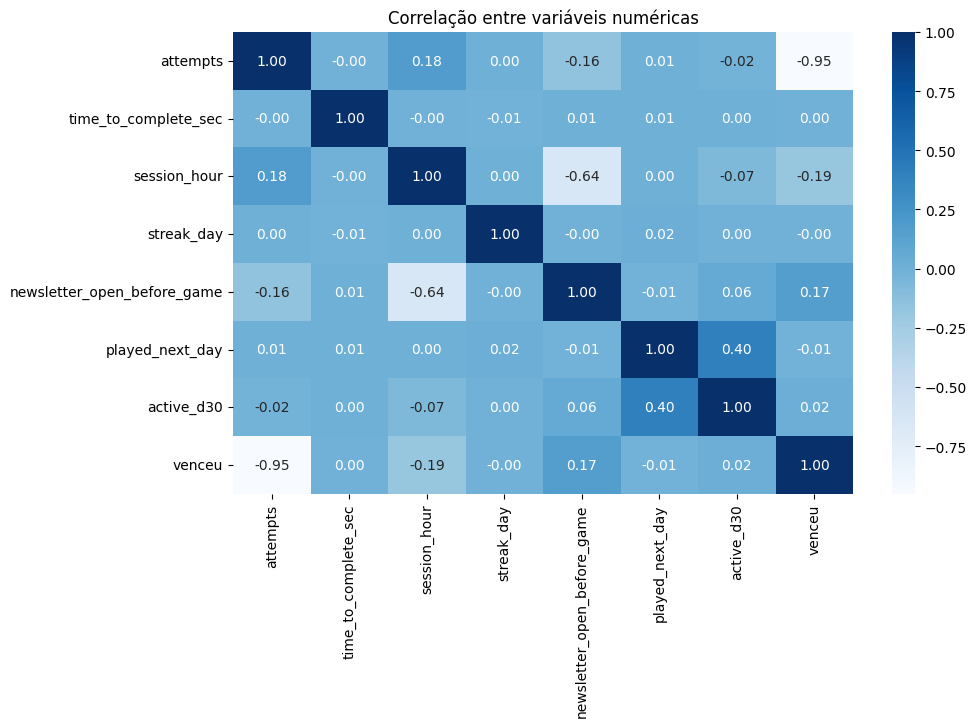

In [33]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlação entre variáveis numéricas")
plt.show()

27. Teste estatístico: newsletter x retorno

In [34]:
tabela_newsletter = pd.crosstab(
    df["newsletter_open_before_game"],
    df["played_next_day"]
)

chi2, p_value, dof, expected = chi2_contingency(tabela_newsletter)

print("Qui-quadrado:", chi2)
print("p-valor:", p_value)

Qui-quadrado: 1.9438264699282628
p-valor: 0.16325366361212362


In [35]:
if p_value < 0.05:
    print("Existe associação estatisticamente significativa.")
else:
    print("Não encontramos associação estatisticamente significativa.")

Não encontramos associação estatisticamente significativa.


28. Modelo para importância das variáveis

In [36]:
model_df = df[[
    "attempts",
    "time_to_complete_sec",
    "session_hour",
    "streak_day",
    "newsletter_open_before_game",
    "venceu",
    "device",
    "periodo_jogo",
    "salary_range",
    "sector",
    "food_delivery_freq_week",
    "plays_other_word_games",
    "played_next_day"
]].copy()

model_df = model_df.dropna()

model_df = pd.get_dummies(
    model_df,
    drop_first=True
)

X = model_df.drop(columns=["played_next_day"])
y = model_df["played_next_day"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modelo = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=6,
    class_weight="balanced"
)

modelo.fit(X_train, y_train)

pred = modelo.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.79      0.62      0.69      4147
        True       0.25      0.44      0.31      1192

    accuracy                           0.58      5339
   macro avg       0.52      0.53      0.50      5339
weighted avg       0.67      0.58      0.61      5339



29. Importância das variáveis

In [37]:
importancia = pd.DataFrame({
    "variavel": X.columns,
    "importancia": modelo.feature_importances_
}).sort_values("importancia", ascending=False)

importancia.head(20)

,variavel,importancia
1,time_to_complete_sec,0.215435
6,food_delivery_freq_week,0.113191
2,session_hour,0.108594
3,streak_day,0.074895
0,attempts,0.051985
23,plays_other_word_games_True,0.037441
7,device_ios,0.036118
14,salary_range_r$4k-r$6k,0.026507
19,sector_outros,0.026456
11,salary_range_até r$2k,0.025333


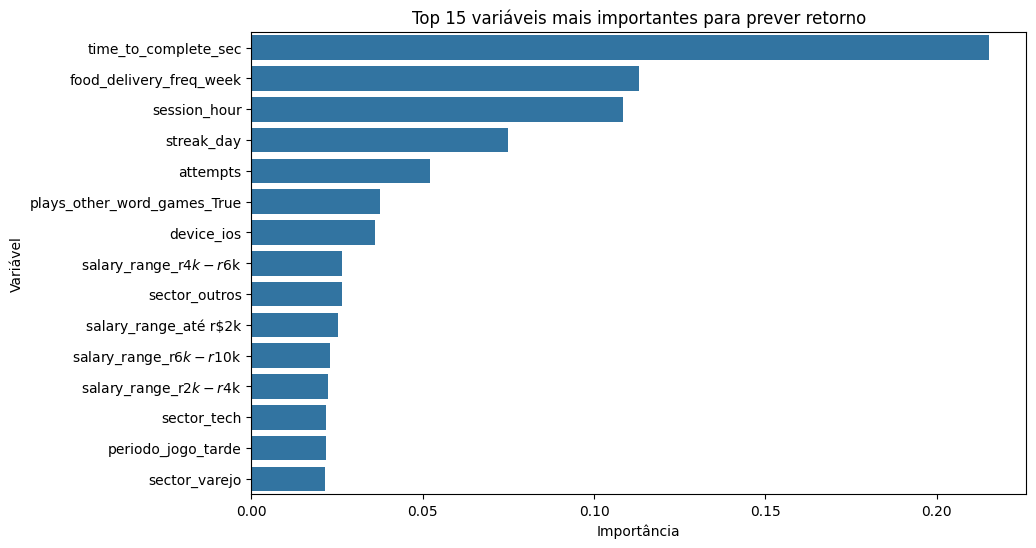

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancia.head(15),
    x="importancia",
    y="variavel"
)

plt.title("Top 15 variáveis mais importantes para prever retorno")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

30. Repetir modelo para Active D30

In [39]:
model_d30 = df[[
    "attempts",
    "time_to_complete_sec",
    "session_hour",
    "streak_day",
    "newsletter_open_before_game",
    "venceu",
    "device",
    "periodo_jogo",
    "salary_range",
    "sector",
    "food_delivery_freq_week",
    "plays_other_word_games",
    "active_d30"
]].copy()

model_d30 = model_d30.dropna()

model_d30 = pd.get_dummies(
    model_d30,
    drop_first=True
)

X = model_d30.drop(columns=["active_d30"])
y = model_d30["active_d30"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modelo_d30 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=6,
    class_weight="balanced"
)

modelo_d30.fit(X_train, y_train)

pred_d30 = modelo_d30.predict(X_test)

print(classification_report(y_test, pred_d30))

              precision    recall  f1-score   support

       False       0.70      0.70      0.70      3619
        True       0.37      0.37      0.37      1720

    accuracy                           0.60      5339
   macro avg       0.54      0.54      0.54      5339
weighted avg       0.60      0.60      0.60      5339



31. Importância para Active D30

In [40]:
importancia_d30 = pd.DataFrame({
    "variavel": X.columns,
    "importancia": modelo_d30.feature_importances_
}).sort_values("importancia", ascending=False)

importancia_d30.head(20)

,variavel,importancia
2,session_hour,0.193238
1,time_to_complete_sec,0.171983
8,periodo_jogo_manhã,0.127113
10,periodo_jogo_noite,0.064667
6,food_delivery_freq_week,0.059992
3,streak_day,0.048707
4,newsletter_open_before_game,0.048184
0,attempts,0.043968
7,device_ios,0.022455
23,plays_other_word_games_True,0.020790


32. Exportar tabelas para relatório ou dashboard

In [41]:
analise_horario.to_csv("analise_horario.csv", index=False)
analise_hora.to_csv("analise_hora.csv", index=False)
analise_newsletter.to_csv("analise_newsletter.csv", index=False)
analise_device.to_csv("analise_device.csv", index=False)
analise_streak.to_csv("analise_streak.csv", index=False)
analise_palavra.to_csv("analise_palavra.csv", index=False)
importancia.to_csv("importancia_variaveis_next_day.csv", index=False)
importancia_d30.to_csv("importancia_variaveis_active_d30.csv", index=False)

33. Resumo executivo automático

In [42]:
print("RESUMO EXECUTIVO")
print("---------------")
print(f"Taxa geral de retorno no dia seguinte: {taxa_next_day:.2%}")
print(f"Taxa geral de active D30: {taxa_active_d30:.2%}")
print(f"Taxa geral de vitória: {taxa_win:.2%}")

print("\nTop variáveis para retorno no dia seguinte:")
display(importancia.head(10))

print("\nTop variáveis para active D30:")
display(importancia_d30.head(10))

RESUMO EXECUTIVO
---------------
Taxa geral de retorno no dia seguinte: 22.14%
Taxa geral de active D30: 31.94%
Taxa geral de vitória: 60.34%

Top variáveis para retorno no dia seguinte:


,variavel,importancia
1,time_to_complete_sec,0.215435
6,food_delivery_freq_week,0.113191
2,session_hour,0.108594
3,streak_day,0.074895
0,attempts,0.051985
23,plays_other_word_games_True,0.037441
7,device_ios,0.036118
14,salary_range_r$4k-r$6k,0.026507
19,sector_outros,0.026456
11,salary_range_até r$2k,0.025333



Top variáveis para active D30:


,variavel,importancia
2,session_hour,0.193238
1,time_to_complete_sec,0.171983
8,periodo_jogo_manhã,0.127113
10,periodo_jogo_noite,0.064667
6,food_delivery_freq_week,0.059992
3,streak_day,0.048707
4,newsletter_open_before_game,0.048184
0,attempts,0.043968
7,device_ios,0.022455
23,plays_other_word_games_True,0.020790
